# Conditioning, orthogonal matrices, and QR

**Conditioning** measures how sensitive $Ax = b$ is to small perturbations in $A$ or $b$.

The condition number $\kappa(A) = \|A\|_2 \|A^{-1}\|_2$ quantifies this. Near 1 is ideal; large means the solution can shift a lot from a tiny change in the data. Rough rule: if $\kappa(A) \approx 10^k$, expect to lose about $k$ digits of accuracy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Geometrically, a matrix maps the unit circle to an ellipse. A well-conditioned matrix produces a roundish ellipse; an ill-conditioned one produces a very thin sliver — some directions are almost collapsed.

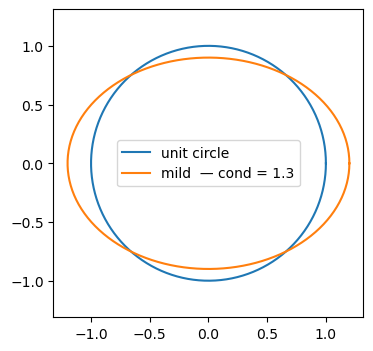

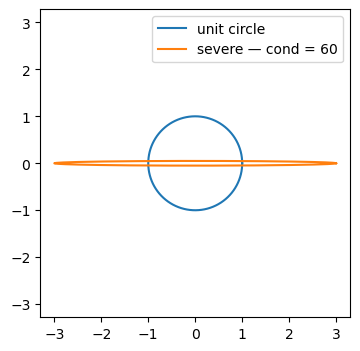

In [2]:
t = np.linspace(0, 2*np.pi, 400)
circle = np.vstack((np.cos(t), np.sin(t)))

A1 = np.array([[1.2, 0.0], [0.0, 0.9]])   # cond ≈ 1.3
A2 = np.array([[3.0, 0.0], [0.0, 0.05]])  # cond ≈ 60

for A, label in [(A1, f"mild  — cond = {np.linalg.cond(A1):.1f}"),
                 (A2, f"severe — cond = {np.linalg.cond(A2):.0f}")]:
    y = A @ circle
    plt.figure(figsize=(4, 4))
    plt.plot(circle[0], circle[1], label="unit circle")
    plt.plot(y[0], y[1], label=label)
    plt.axis("equal")
    plt.legend()
    plt.show()

Here's a concrete example. $A$ has a large off-diagonal entry, which makes it sensitive. A small perturbation in $x$ produces a large relative residual, and $\kappa(A)$ predicts this:

In [3]:
A = np.array([[1, 1000], [0, 1]], dtype=float)
b = np.array([0.0, 1.0])

x = np.linalg.solve(A, b)
x_perturbed = x + np.array([0.001, 0.001])

print("x           =", x)
print("x_perturbed =", x_perturbed)
print()
print("A @ x           =", A @ x)
print("A @ x_perturbed =", A @ x_perturbed)
print()
print("relative residual:", np.linalg.norm(b - A @ x_perturbed) / np.linalg.norm(b))
print("cond(A)          =", np.linalg.cond(A))

x           = [-1000.     1.]
x_perturbed = [-999.999    1.001]

A @ x           = [0. 1.]
A @ x_perturbed = [1.001 1.001]

relative residual: 1.001000499500241
cond(A)          = 1000001.9999990001


A tiny shift in $x$ caused a ~100% relative residual. The condition number predicted it: $\kappa(A) \approx 10^6$ means roughly 6 digits of accuracy are at risk.

One common cause: nearly dependent columns. The matrix is nearly singular and $\kappa(A)$ blows up.

In [4]:
eps = 1e-4
A = np.array([[1.0, 1.0],
                  [1.0, 1.0 + eps]])

print("A =")
print(A)
print("cond(A) =", np.linalg.cond(A))

A =
[[1.     1.    ]
 [1.     1.0001]]
cond(A) = 40002.000074915224


As `eps` shrinks toward zero, the two columns become identical and $\kappa$ diverges. The plot makes this concrete:

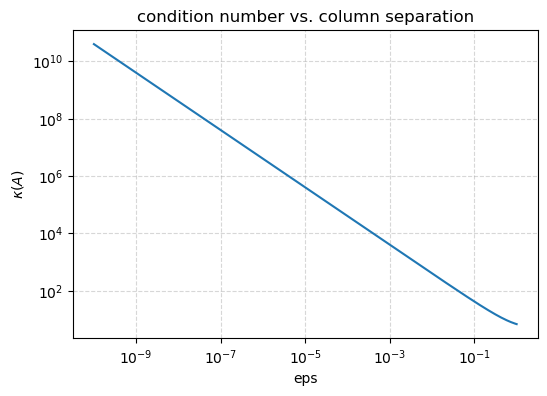

In [5]:
epsilons = np.logspace(-10, 0, 300)
kappas = [np.linalg.cond(np.array([[1., 1.], [1., 1. + e]])) for e in epsilons]

plt.figure(figsize=(6, 4))
plt.loglog(epsilons, kappas)
plt.xlabel("eps")
plt.ylabel(r"$\kappa(A)$")
plt.title("condition number vs. column separation")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

Now solve two almost identical systems.

The right-hand sides differ only slightly, but the solutions can differ a lot.

In [6]:
b1 = np.array([2.0, 2.0])
b2 = np.array([2.0, 2.0001])

x1 = np.linalg.solve(A, b1)
x2 = np.linalg.solve(A, b2)

print("x1 =", x1)
print("x2 =", x2)
print("difference in b =", np.linalg.norm(b2 - b1))
print("difference in x =", np.linalg.norm(x2 - x1))

x1 = [2. 0.]
x2 = [1. 1.]
difference in b = 0.00010000000000021103
difference in x = 1.4142135623762353


This is what bad conditioning looks like. A tiny change in $b$ caused a huge change in $x$.

Note: this is a property of the *problem*, not the algorithm. An ill-conditioned problem is hard for every solver.

Orthogonal matrices are the opposite extreme.

A matrix $Q$ is orthogonal if

$$
Q^T Q = I.
$$

Geometrically, orthogonal matrices rotate or reflect space. They do not stretch it.

So for every vector $x$,

$$
\|Qx\|_2 = \|x\|_2.
$$

They preserve lengths, angles, and inner products.

In [7]:
theta = np.pi/5
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

v = np.array([2.0, 1.0])

print("||v|| =", np.linalg.norm(v))
print("||Qv|| =", np.linalg.norm(Q @ v))
print("cond(Q) =", np.linalg.cond(Q))

||v|| = 2.23606797749979
||Qv|| = 2.23606797749979
cond(Q) = 1.0000000000000002


In [8]:
def is_orthogonal(M, tol=1e-8):
    n = M.shape[0]
    return np.allclose(M @ M.T, np.eye(n), atol=tol)

print("Q orthogonal?", is_orthogonal(Q))
print("Q.T @ Q =\n", np.round(Q.T @ Q, 10))

Q orthogonal? True
Q.T @ Q =
 [[ 1. -0.]
 [-0.  1.]]


Why is $\kappa(Q) = 1$? Because $Q^{-1} = Q^T$, and both have 2-norm equal to 1:

$$
\kappa(Q) = \|Q\|_2 \|Q^{-1}\|_2 = 1 \cdot 1 = 1.
$$

Multiplying by $Q$ moves information around without amplifying errors. Best possible condition number.

This is why QR is useful. Factor $A = QR$ where $Q$ is orthogonal and $R$ is upper triangular. Then $Ax = b$ becomes

$$
QRx = b \implies Rx = Q^T b.
$$

Multiply by $Q^T$ (free — no error amplification), then back-solve the triangular system. The orthogonal step can't make conditioning worse.

In [9]:
A = np.array([[2.0, 1.0],
              [1.0, 3.0]])

b = np.array([1.0, 2.0])

Q, R = np.linalg.qr(A)
x = np.linalg.solve(R, Q.T @ b)

print("solution from QR =", x)
print("direct solution  =", np.linalg.solve(A, b))
print()
print("is Q orthogonal? ", is_orthogonal(Q))
print("relative residual ||A - QR|| / ||A|| =", np.linalg.norm(A - Q @ R) / np.linalg.norm(A))

solution from QR = [0.2 0.6]
direct solution  = [0.2 0.6]

is Q orthogonal?  True
relative residual ||A - QR|| / ||A|| = 1.8129866073473578e-16


In [13]:
A = np.array([np.random.rand(3), 2*np.ones(3), 3*np.ones(3)])
np.linalg.cond(A)

1.2959033627662555e+17

**Summary.** Bad conditioning = uneven stretching. Orthogonal matrices don't stretch at all ($\kappa = 1$). QR splits the work: the $Q$ factor is harmless, leaving only a triangular solve. That's why QR is a stable algorithm for solving linear systems.